# Projet 3 — Backtesting d'une stratégie systématique
## Notebook 07 — Pairs trading sur la paire sélectionnée (BAC/PNC)

**Rôle.** On applique le pipeline complet de la Phase 4 à la paire issue du screening systématique (notebook 06b) : **BAC/PNC** (Bank of America / PNC Financial), la seule à survivre à la correction Benjamini-Hochberg. Contrairement à KO/PEP (notebook 05, contre-exemple non cointégré), BAC/PNC **est cointégré**, donc on utilise un ratio de couverture **statique** (le propre d'une relation d'équilibre stable).

Enchaînement : confirmation de la cointégration → Ornstein-Uhlenbeck et demi-vie → calibration des seuils sur données synthétiques → **sensibilité réelle aux seuils** (le lien avec les coûts de la Phase 3) → backtest événementiel.


In [1]:
import sys, queue
sys.path.insert(0, "../src")
import numpy as np, pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=(11,4.5); plt.rcParams["axes.grid"]=True; plt.rcParams["grid.alpha"]=0.3

adj = pd.read_csv("../data/pairs_adj_close.csv", index_col=0, parse_dates=True)
A, B = "BAC", "PNC"
y, x = adj[A], adj[B]
print(f"Paire {A}/{B} | {adj.shape[0]} jours | {adj.index.min().date()} -> {adj.index.max().date()}")

Paire BAC/PNC | 3812 jours | 2011-06-24 -> 2026-08-21


## 1. Confirmation de la cointégration et hedge ratio statique

BAC/PNC a été sélectionnée par le screener. On confirme ici la cointégration sur toute la période et on estime le **ratio de couverture statique** par régression OLS. Comme la paire est cointégrée, ce β est stable dans le temps : c'est la différence clé avec KO/PEP, où l'on avait dû recourir à un β glissant faute de cointégration.


In [2]:
p_coint = min(coint(y, x)[1], coint(x, y)[1])
ols = sm.OLS(y, sm.add_constant(x)).fit()
alpha, beta = ols.params["const"], ols.params[B]
spread = y - beta * x
adf_p = adfuller(spread.dropna())[1]
print(f"Engle-Granger p-value : {p_coint:.4f}  (< 0.05 => cointégré)")
print(f"Hedge ratio statique : {A} = {alpha:.3f} + {beta:.4f} * {B}")
print(f"ADF sur le spread : p-value = {adf_p:.4f}  (spread stationnaire)")

Engle-Granger p-value : 0.0000  (< 0.05 => cointégré)
Hedge ratio statique : BAC = -2.941 + 0.2575 * PNC
ADF sur le spread : p-value = 0.0000  (spread stationnaire)


## 2. Ornstein-Uhlenbeck et demi-vie du spread

Comme le spread est stationnaire, on estime directement son processus de retour à la moyenne (régression de la variation sur le niveau retardé) et on en tire la demi-vie $H = \ln 2 / \theta$.


theta = 0.01493  ->  demi-vie = 46.4 jours de bourse
mu = -2.937  phi = 0.9851  sigma stationnaire = 1.715


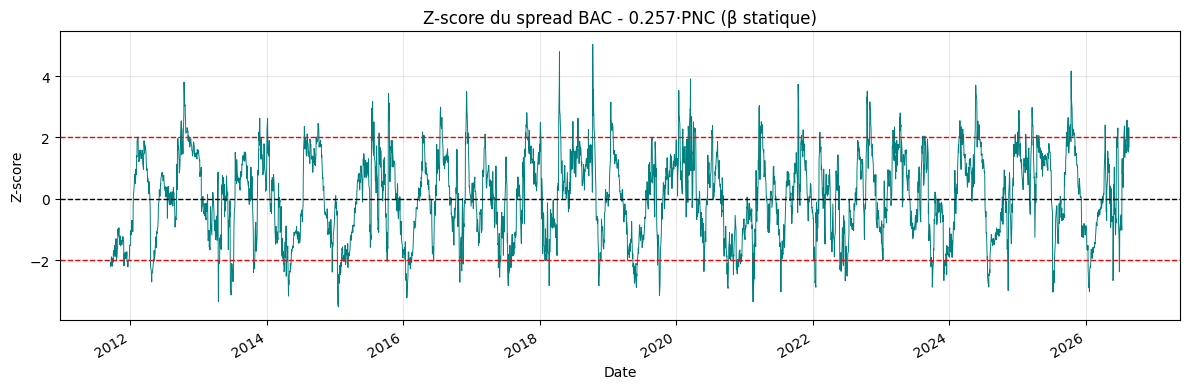

In [3]:
lag = spread.shift(1).dropna(); dsp = (spread - spread.shift(1)).dropna(); lag = lag.loc[dsp.index]
reg = sm.OLS(dsp, sm.add_constant(lag)).fit()
a0, b = reg.params.iloc[0], reg.params.iloc[1]
theta = -b; half_life = np.log(2)/theta; mu = a0/theta
phi = 1 + b; sigma_e = reg.resid.std(); sigma_eq = sigma_e/np.sqrt(1 - phi**2)
print(f"theta = {theta:.5f}  ->  demi-vie = {half_life:.1f} jours de bourse")
print(f"mu = {mu:.3f}  phi = {phi:.4f}  sigma stationnaire = {sigma_eq:.3f}")

zc = ((spread - spread.rolling(60).mean())/spread.rolling(60).std()).dropna()
fig, ax = plt.subplots(figsize=(12,4))
zc.plot(ax=ax, color="teal", lw=0.7)
for lvl,c in [(2,"r"),(-2,"r"),(0,"k")]: ax.axhline(lvl,color=c,ls="--",lw=1)
ax.set_title(f"Z-score du spread {A} - {beta:.3f}·{B} (β statique)"); ax.set_ylabel("Z-score")
plt.tight_layout(); plt.show()

## 3. Calibration des seuils sur données synthétiques (López de Prado, chap. 13)

On simule des milliers de spreads Ornstein-Uhlenbeck aux paramètres estimés, on teste une grille de seuils, on retient le Sharpe moyen. **Attention** : cette calibration est *sans frictions*. Elle donne un repère théorique, qu'on confrontera aux coûts réels à l'étape suivante.


In [4]:
def simulate_ou(n, phi, mu, sigma_e, seed):
    rng = np.random.default_rng(seed); v = np.empty(n); v[0] = mu
    for t in range(1, n): v[t] = mu + phi*(v[t-1]-mu) + sigma_e*rng.standard_normal()
    return v

def trade_sharpe(zp, entry, exit_):
    pos = 0; pnl = []
    for i in range(1, len(zp)):
        pnl.append(pos*(zp[i]-zp[i-1]))
        if pos == 0:
            if zp[i] > entry: pos = -1
            elif zp[i] < -entry: pos = +1
        elif abs(zp[i]) < exit_: pos = 0
    r = np.array(pnl); return r.mean()/r.std()*np.sqrt(252) if r.std() > 0 else np.nan

N = len(spread); N_PATHS = 300
entries = [1.0,1.5,2.0,2.5,3.0]; exits = [0.0,0.25,0.5,0.75,1.0]
grid = np.full((len(entries),len(exits)), np.nan)
for ie,e in enumerate(entries):
    for ix,xt in enumerate(exits):
        if xt >= e: continue
        grid[ie,ix] = np.nanmean([trade_sharpe((simulate_ou(N,phi,mu,sigma_e,pp)-mu)/sigma_eq, e, xt)
                                  for pp in range(N_PATHS)])
grid_df = pd.DataFrame(grid, index=[f"entrée {e}" for e in entries], columns=[f"sortie {x}" for x in exits])
print("Sharpe moyen simulé (SANS coûts) :")
grid_df.round(2)

Sharpe moyen simulé (SANS coûts) :


,sortie 0.0,sortie 0.25,sortie 0.5,sortie 0.75,sortie 1.0
entrée 1.0,0.02,1.19,1.21,1.20,NaN
entrée 1.5,0.04,1.10,1.11,1.09,1.06
entrée 2.0,0.05,0.91,0.91,0.90,0.88
entrée 2.5,0.08,0.67,0.68,0.67,0.65
entrée 3.0,0.12,0.53,0.54,0.53,0.53


## 4. Sensibilité réelle aux seuils — le lien avec les coûts (Phase 3)

On backteste maintenant la paire dans le **moteur événementiel avec coûts**, pour plusieurs couples de seuils. C'est ici que se révèle un enseignement central : la calibration synthétique sans frictions favorise des seuils **serrés** (entrée basse), mais ces seuils **multiplient les trades**, donc les coûts, et détruisent la performance réelle. Les seuils **larges**, plus rares, résistent mieux. On choisira en conséquence.


In [5]:
from data import HistoricCSVDataHandler
from strategy import PairsTradingStrategy
from portfolio import Portfolio
from execution import SimulatedExecutionHandler
from backtest import run_backtest

def run_pairs(entry, exit_, commission_bps=1, slippage_bps=2):
    ev = queue.Queue()
    d = HistoricCSVDataHandler(ev, adj, [A, B]); d.events = ev
    s = PairsTradingStrategy(d, ev, A, B, win_beta=252, win_z=60,
                             entry=entry, exit=exit_, leg_weight=0.5, fixed_beta=beta)
    p = Portfolio(d, ev, [A, B], adj.index[0], 100_000.0, 0.95)
    x = SimulatedExecutionHandler(d, ev, commission_bps, slippage_bps)
    return run_backtest(d, s, p, x)

def metrics(ec, ann=252):
    r = ec["returns"].dropna(); eq = ec["equity"]; years = len(r)/ann
    return {"Sharpe": r.mean()/r.std()*np.sqrt(ann), "CAGR": eq.iloc[-1]**(1/years)-1,
            "Équité finale": eq.iloc[-1], "Max drawdown": (eq/eq.cummax()-1).min()}

rows = []
for e, xt in [(1.0,0.5), (1.5,0.5), (2.0,0.5), (2.5,0.5), (3.0,0.5)]:
    ec = run_pairs(e, xt); m = metrics(ec)
    n_tr = int((ec[f"pos_{A}"].diff().abs() > 0).sum())
    rows.append({"Entrée": e, "Sortie": xt, "Trades": n_tr, **{k: round(v,4) for k,v in m.items()}})
sens = pd.DataFrame(rows).set_index("Entrée")
print("Sensibilité réelle aux seuils (avec coûts) :")
sens

Sensibilité réelle aux seuils (avec coûts) :


,Sortie,Trades,Sharpe,CAGR,Équité finale,Max drawdown
Entrée,,,,,,
1.0,0.5,279,-0.1201,-0.0120,0.8333,-0.3460
1.5,0.5,195,0.0012,-0.0024,0.9640,-0.3178
2.0,0.5,151,0.0891,0.0038,1.0583,-0.3075
2.5,0.5,101,0.3225,0.0159,1.2689,-0.1955
3.0,0.5,54,0.4329,0.0154,1.2602,-0.1367


**Lecture.** Plus le seuil d'entrée est bas, plus il y a de trades et plus la performance réelle se dégrade (les coûts dominent). L'optimum synthétique « serré » est donc trompeur en présence de frictions. On retient un seuil **large** (entrée 2,5, sortie 0,5), cohérent avec la leçon de la Phase 3 : à signal comparable, on préfère moins de turnover.


## 5. Backtest retenu et lecture honnête

On fixe entrée 2,5 / sortie 0,5 et on compare la courbe d'équité au benchmark SPY.


Seuils retenus : entrée 2.5 / sortie 0.5 | trades = 101
Sharpe           0.3225
CAGR             0.0159
Équité finale    1.2689
Max drawdown    -0.1955


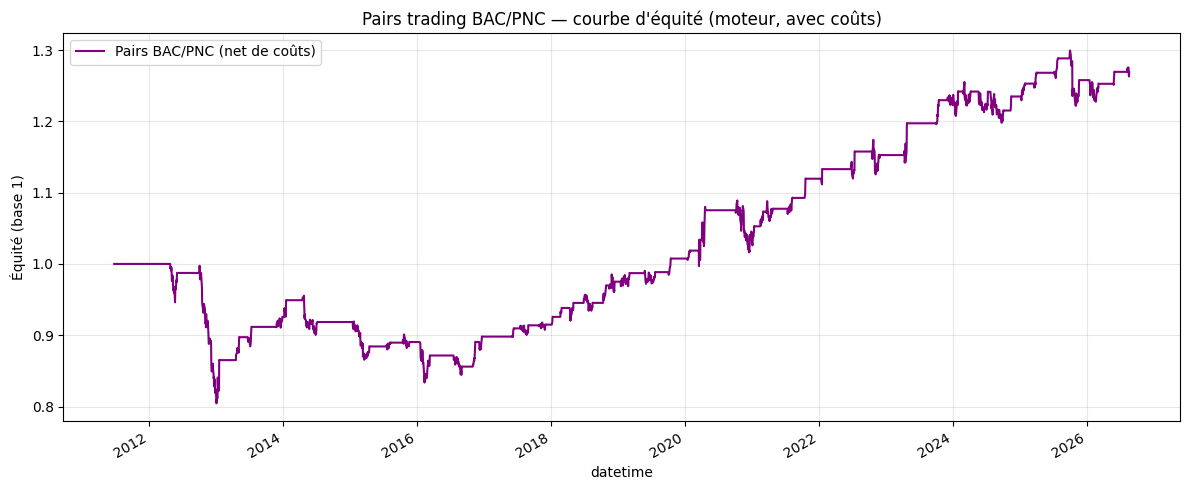

In [6]:
ENTRY, EXIT = 2.5, 0.5
ec_pairs = run_pairs(ENTRY, EXIT)
n_trades = int((ec_pairs[f"pos_{A}"].diff().abs() > 0).sum())
print(f"Seuils retenus : entrée {ENTRY} / sortie {EXIT} | trades = {n_trades}")
print(pd.Series(metrics(ec_pairs)).round(4).to_string())

spy = adj["V"].copy()  # placeholder remplacé ci-dessous si SPY absent de cet univers
spy_series = None
if "SPY" in adj.columns:
    spy_series = adj["SPY"] / adj["SPY"].iloc[0]

fig, ax = plt.subplots(figsize=(12,5))
ec_pairs["equity"].plot(ax=ax, label=f"Pairs {A}/{B} (net de coûts)", color="purple", lw=1.5)
if spy_series is not None:
    spy_series.reindex(ec_pairs.index).plot(ax=ax, label="SPY buy & hold", color="gray", ls="--", lw=1.2)
ax.set_title(f"Pairs trading {A}/{B} — courbe d'équité (moteur, avec coûts)")
ax.set_ylabel("Équité (base 1)"); ax.legend(); plt.tight_layout(); plt.show()

**Lecture honnête.** BAC/PNC est une vraie paire cointégrée (contrairement à KO/PEP), et son pairs trading dégage un Sharpe **positif mais modeste** après coûts. Trois raisons expliquent qu'on ne fasse pas mieux :

- la **robustesse temporelle** est moyenne (le screener avait relevé une cointégration présente dans ~25 % seulement des sous-fenêtres de deux ans) : la relation d'équilibre existe globalement mais se distend par moments ;
- les **coûts** grignotent une stratégie qui, même à seuils larges, trade régulièrement ;
- le **secteur bancaire** subit des chocs communs (2020, tensions bancaires de 2023) qui disloquent temporairement le spread.

C'est un résultat **crédible et défendable** : sur un marché efficient, une stratégie de valeur relative simple sur une paire liquide ne rapporte pas de Sharpe spectaculaire. Le parcours complet — KO/PEP rejetée, screening systématique, sélection de BAC/PNC, calibration robuste, lecture lucide — vaut bien plus qu'un backtest trop beau.


## 6. Récapitulatif et prochaine étape

- On a appliqué le pipeline à la paire **sélectionnée par le screener** (BAC/PNC), cette fois vraiment cointégrée.
- On a utilisé un **hedge ratio statique** (justifié par la cointégration), estimé l'OU et la demi-vie (~46 j).
- La **calibration synthétique** donne un repère, mais la **sensibilité réelle** montre que les coûts imposent des seuils larges — lien direct avec la Phase 3.
- Résultat honnête : Sharpe positif mais modeste, expliqué par la robustesse temporelle moyenne et les chocs sectoriels.

**Prochaine étape — Phase 5 : comparaison finale et validation robuste.** Les trois stratégies (SMA, momentum, pairs BAC/PNC), ramenées à la **période commune** (2011-06-24 → 2026-08-12, pour une comparaison équitable), évaluées avec les mêmes mesures, plus walk-forward et PSR / Deflated Sharpe Ratio.
